In [65]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [66]:
#Descargar set de datos de Fashion MNIST de Zalando
datos, metadatos = tfds.load('rock_paper_scissors', as_supervised=True, with_info=True)

In [67]:
#Imprimir los metadatos para ver que trae el set
metadatos

tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    full_name='rock_paper_scissors/3.0.0',
    description="""
    Images of hands playing rock, paper, scissor game.
    """,
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    data_dir='/root/tensorflow_datasets/rock_paper_scissors/3.0.0',
    file_format=tfrecord,
    download_size=219.53 MiB,
    dataset_size=219.23 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=372, num_shards=1>,
        'train': <SplitInfo num_examples=2520, num_shards=2>,
    },
    citation="""@ONLINE {rps,
    author = "Laurence Moroney",
    title = "Rock, Paper, Scissors Dataset",
    month = "feb",
    year = "2019",
    url = "http://laurencemoroney.com/rock

In [68]:
#Obtenemos en variables separadas los datos de entrenamiento (60k) y pruebas (10k)
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [69]:
#Etiquetas de las 10 categorias posibles
nombres_clases = metadatos.features['label'].names

In [70]:
nombres_clases

['rock', 'paper', 'scissors']

In [ ]:
#Funcion de normalizacion para los datos (Pasar de 0-255 a 0-1)
#Hace que la red aprenda mejor y mas rapido
IMG_SIZE = 128


def normalizar(imagen, etiqueta):
    imagen = tf.image.resize(imagen, (IMG_SIZE,IMG_SIZE))
    imagen = tf.cast(imagen, tf.float32) / 255.0
    return imagen, etiqueta

#Normalizar los datos de entrenamiento y pruebas con la funcion que hicimos
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

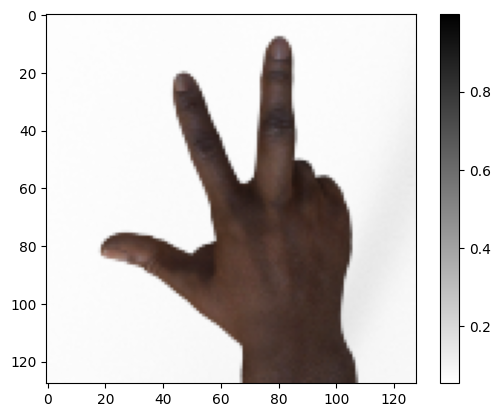

In [72]:
#Mostrar una imagen de los datos de pruebas, de momento mostremos la primera
for imagen, etiqueta in datos_entrenamiento.take(1):
  break
imagen = imagen.numpy() #Redimensionar, cosas de tensores, lo veremos despues

import matplotlib.pyplot as plt

#Dibujar dibujar
plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

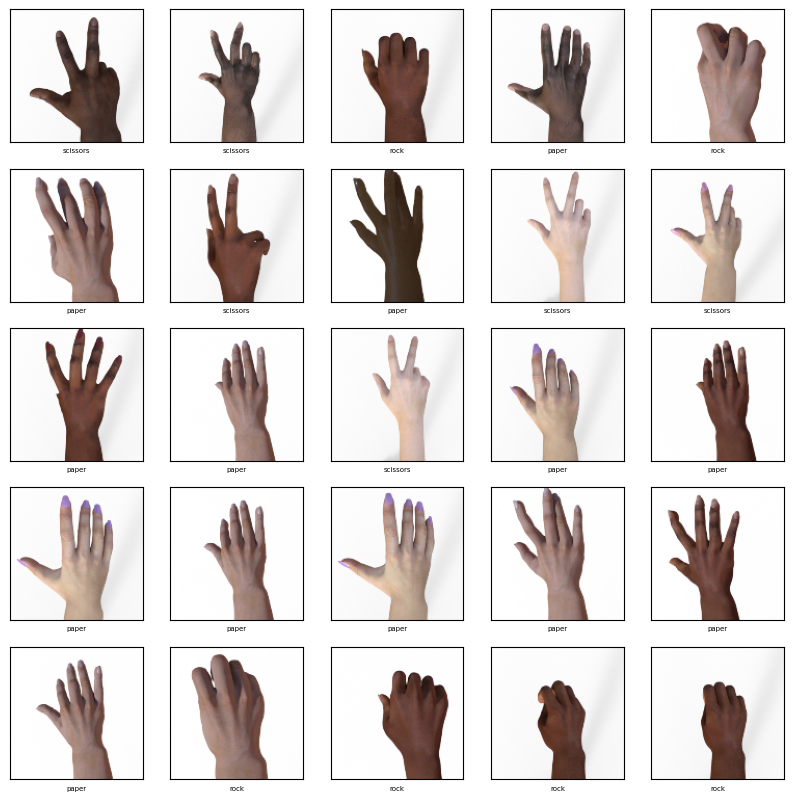

In [73]:
#Dibujar mas
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
  imagen = imagen.numpy()
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(imagen, cmap=plt.cm.binary)
  plt.xlabel(nombres_clases[etiqueta],  fontsize=5)
plt.show()

In [ ]:
#Crear el modelo
modelo = tf.keras.Sequential([
  tf.keras.layers.Conv2D(32, (3,3), padding="same", activation='relu',input_shape=(128,128,3)),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(64, (3,3), padding="same", activation='relu'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.MaxPooling2D(2,2),

  tf.keras.layers.GlobalAveragePooling2D(),
  tf.keras.layers.Dense(128,activation="relu"),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(3, activation="softmax")
])
modelo.summary()

In [75]:
#Compilar el modelo
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)


In [76]:
#Los numeros de datos en entrenamiento y pruebas (60k y 10k)
num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples

In [ ]:
print(num_ej_entrenamiento)
print(num_ej_pruebas)

2520
372


In [ ]:
#El trabajo por lotes permite que entrenamientos con gran cantidad de datos se haga de manera mas eficiente
TAMANO_LOTE = 16
#Shuffle y repeat hacen que los datos esten mezclados de manera aleatoria para que la red
#no se vaya a aprender el orden de las cosas
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)
print(TAMANO_LOTE)


16


In [ ]:
import math

stop = tf.keras.callbacks.EarlyStopping( 
    monitor='val_loss',patience=3,
    restore_best_weights=True
)

class detenerplis(tf.keras.callbacks.Callback):
    def termina(self, epoch, logs=None):
        valac = logs.get('val_accuracy')
        if valac is not None and valac>=0.95:
            self.model.stop_training = True

historial= modelo.fit(datos_entrenamiento,epochs=20,validation_data=datos_pruebas,callbacks=[stop, detenerplis()],steps_per_epoch=math.ceil(num_ej_entrenamiento / TAMANO_LOTE))

Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 124s 715ms/step - accuracy: 0.6586 - loss: 0.7848 - val_accuracy: 0.3333 - val_loss: 1.1360
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 62s 392ms/step - accuracy: 0.8952 - loss: 0.3432 - val_accuracy: 0.3333 - val_loss: 1.0938
Epoch 3/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 63s 396ms/step - accuracy: 0.9407 - loss: 0.2019 - val_accuracy: 0.6747 - val_loss: 0.9866
Epoch 4/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - accuracy: 0.9553 - loss: 0.1504 - val_accuracy: 0.5134 - val_loss: 1.4142
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 62s 395ms/step - accuracy: 0.9763 - loss: 0.0949 - val_accuracy: 0.3710 - val_loss: 16.0288
Epoch 6/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 63s 399ms/step - accuracy: 0.9739 - loss: 0.1011 - val_accuracy: 0.3333 - val_loss: 16.4408


In [80]:
#import math

#Entrenar
#historial = modelo.fit(datos_entrenamiento, epochs=3, validation_data=datos_pruebas, steps_per_epoch= math.ceil(num_ej_entrenamiento/TAMANO_LOTE))

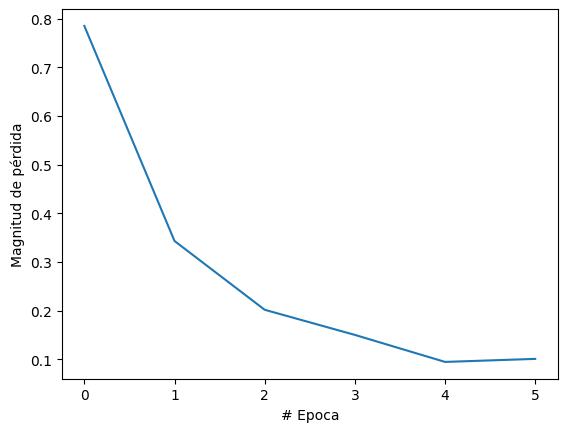

In [ ]:
#Ver la funcion de perdida
plt.xlabel("Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])

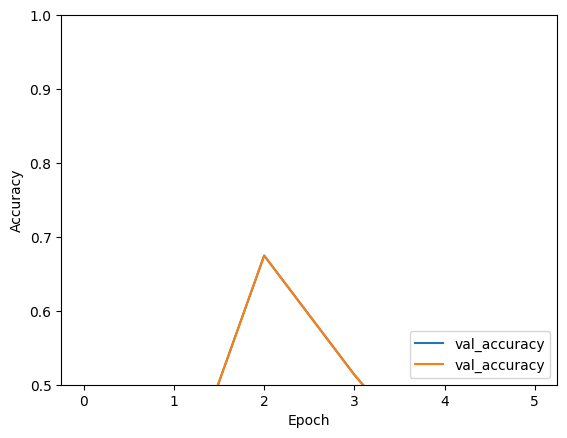

In [ ]:

plt.plot(historial.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5,1])
plt.legend(loc='lower right')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step


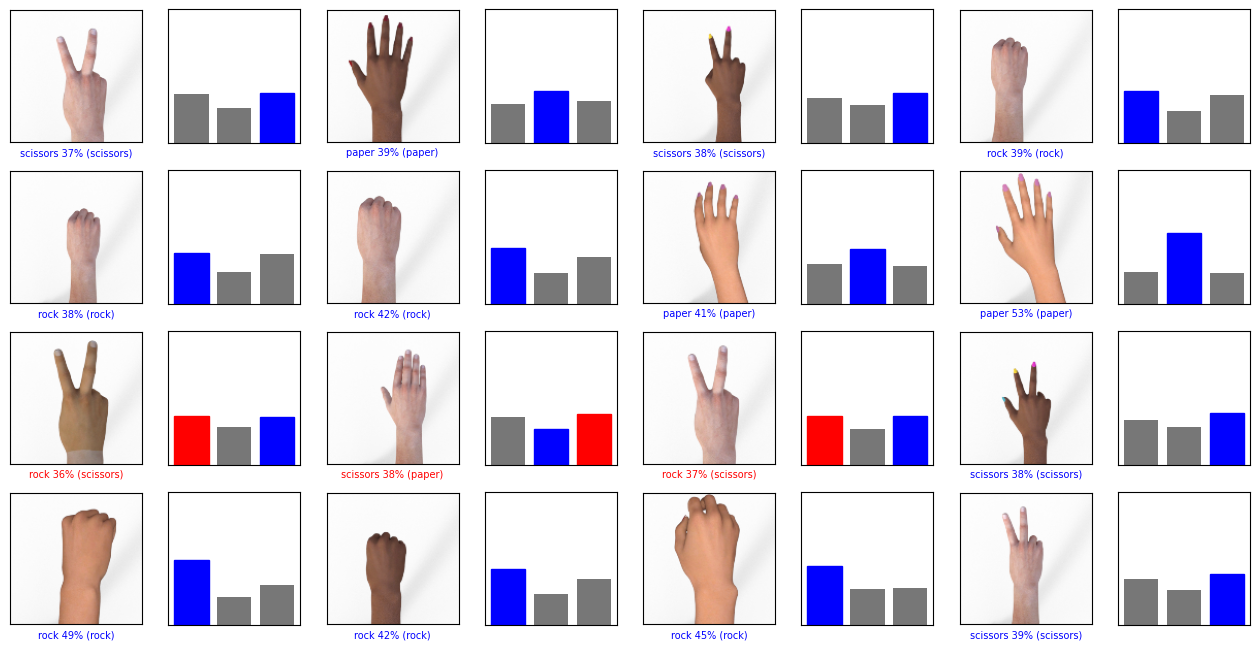

In [83]:
#Pintar una cuadricula con varias predicciones, y marcar si fue correcta (azul) o incorrecta (roja)
import numpy as np

for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
  imagenes_prueba = imagenes_prueba.numpy()
  etiquetas_prueba = etiquetas_prueba.numpy()
  predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
  arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  etiqueta_prediccion = np.argmax(arr_predicciones)
  if etiqueta_prediccion == etiqueta_real:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(nombres_clases[etiqueta_prediccion],
                                100*np.max(arr_predicciones),
                                nombres_clases[etiqueta_real]),
                                fontsize=7,
                                color=color)

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
  arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  grafica = plt.bar(range(3), arr_predicciones, color="#777777")
  plt.ylim([0, 1])
  etiqueta_prediccion = np.argmax(arr_predicciones)

  grafica[etiqueta_prediccion].set_color('red')
  grafica[etiqueta_real].set_color('blue')

filas = 4
columnas = 4
num_imagenes = filas*columnas
plt.figure(figsize=(2*2*columnas, 2*filas))
for i in range(num_imagenes):
  plt.subplot(filas, 2*columnas, 2*i+1)
  graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
  plt.subplot(filas, 2*columnas, 2*i+2)
  graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediccion: scissors


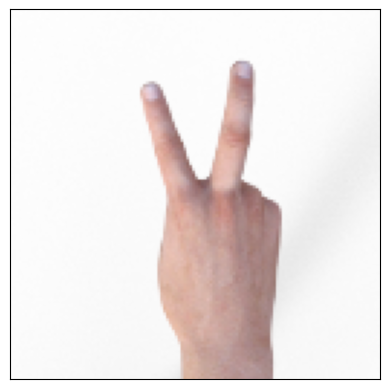

In [91]:
#Probar una imagen suelta
imagen = imagenes_prueba[i] #AL ser la variable imagenes_prueba solo tiene lo que se le puso en el bloque anterior heheh
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)

def graficar_imagensola(i, imagenes):
  img =  imagenes[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img)

graficar_imagensola(0, imagenes_prueba)
print("Prediccion: " + nombres_clases[np.argmax(prediccion[0])])

In [95]:
print("VARIABLE ACC: ", historial.history["val_accuracy"])

VARIABLE ACC:  [0.3333333432674408, 0.3333333432674408, 0.6747311949729919, 0.5134408473968506, 0.3709677457809448, 0.3333333432674408]


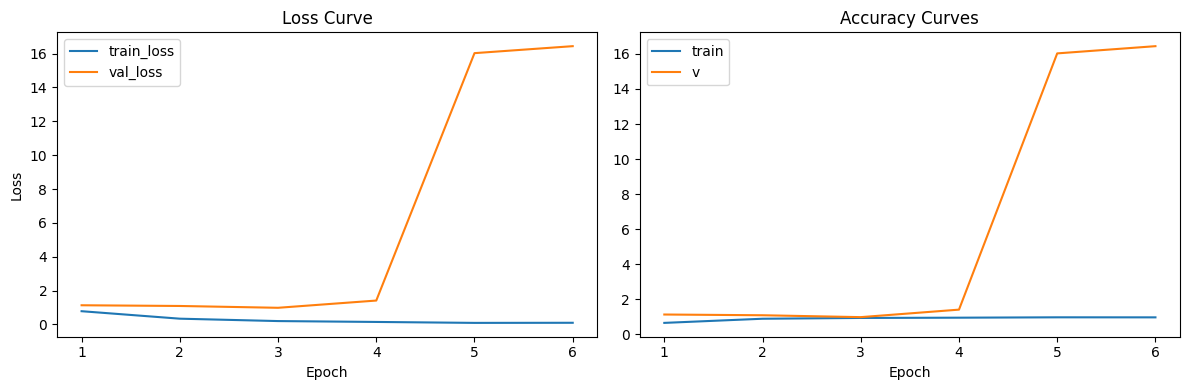

In [103]:
def plot_history(hist): 
    h= hist.history
    epochs_ran = range(1, len(h["loss"])+1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_ran, h["loss"], label="train_loss")
    plt.plot(epochs_ran, h["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")


    plt.subplot(1, 2, 2)
    plt.plot(epochs_ran, h["accuracy"], label="train")
    plt.xlabel("Epoch")
    plt.plot(epochs_ran, h["val_loss"],label="v")
    plt.legend()
    plt.title("Accuracy Curves")
    plt.tight_layout()
    plt.show()

plot_history(historial)